# Discrete State Space
## Numerical Experiments

This notebook compares our implementation of the simplex-perturbed MF-REINFORCE with the implementation of [Meunier2026] using his logits transformation, for three benchmarks:
- Two-State Two-Action Toy Problem,
- Cybersecurity,
- Distribution Planning.

Both the implemented logits-perturbed MF-REINFORCE from [Meunier2026] and the simplex-perturbed MF-REINFORCE algorithm are model-free and estimate the population flow, allowing for a fair comparison.

References:
- [Meunier2026] Meunier, M., Pham, H. and Reisinger, C., 2026. Model-free policy gradient for discrete-time mean-field control. arXiv preprint arXiv:2601.11217.
- [6] René Carmona, Mathieu Laurière, and Zongjun Tan. Model-free mean-field reinforcement learning: mean-field MDP and mean-field Q-learning. The Annals of Applied Probability, 33(6B):5334–5381, 2023
- [17] Haotian Gu, Xin Guo, Xiaoli Wei, and Renyuan Xu. Dynamic programming principles for mean-field controls with learning. Operations Research, 71(4):1040–1054, 2023.
- [24] Diederik P Kingma. Adam: A method for stochastic optimization. arXiv preprint arXiv:1412.6980, 2014.
- [25] Vassili N Kolokoltsov and Alain Bensoussan. Mean-field-game model for botnet defense in cybersecurity. Applied Mathematics & Optimization, 74(3):669–692, 2016


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, List, Literal, Optional, Tuple, Union
import sys, time, logging, importlib
from pathlib import Path

import math
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

ROOT = Path('..').resolve()
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from mfc.algorithms import SimplexPerturbedMFREINFORCE, LogitsPerturbedMFREINFORCE
from mfc.environments import TwoStateMFC, TwoStateConfig
from mfc.environments import CybersecurityMFC, CybersecurityConfig, CybersecurityPolicy
from mfc.environments import DistributionPlanningMFC, DistributionPlanningConfig, DistributionPlanningPolicy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)

def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)

set_seed(0)
print(device)


cuda


In [2]:
# Training helper
def format_runtime(seconds: float) -> str:
    seconds = float(seconds)
    hours, remainder = divmod(int(seconds), 3600)
    minutes, secs = divmod(remainder, 60)
    if hours:
        return f"{hours:d}h {minutes:02d}m {secs:02d}s"
    if minutes:
        return f"{minutes:d}m {secs:02d}s"
    return f"{seconds:.1f}s"


def aligned_validation_history(runs):
    min_len = min(len(run["history"]["validation_value"]) for run in runs)
    episodes = np.asarray(runs[0]["history"]["episode"][:min_len], dtype=float)
    values = np.asarray([run["history"]["validation_value"][:min_len] for run in runs], dtype=float)
    return episodes, values


def train_simplex_mfreinforce(
    env_cls,
    config,
    epsilon_range,
    flow_particles: int,
    policy_cls=None,
    train_horizon=None,
    validation_horizon=None,
    save_final_distribution: bool = False,
    label: str = "",
    early_stopping_patience: Optional[int] = None,
    early_stopping_min_delta: float = 0.0,
    max_runtime_seconds: Optional[float] = None,
    save_dir: Union[str, Path] = ROOT / "models" / "SimplexMFREINFORCE",
):
    results = {}
    train_horizon = train_horizon if train_horizon is not None else getattr(config, "T_train", getattr(config, "T", None))
    validation_horizon = validation_horizon if validation_horizon is not None else getattr(config, "T_val", None)
    fixed_mu0 = (
        torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)
        if hasattr(config, "low") and hasattr(config, "high")
        else torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)
    )
    name = label or env_cls.__name__
    safe_name = "".join(ch.lower() if ch.isalnum() else "_" for ch in name).strip("_") or env_cls.__name__.lower()
    save_root = Path(save_dir) / safe_name
    save_root.mkdir(parents=True, exist_ok=True)
    total_start = time.perf_counter()

    for eps in epsilon_range:
        eps_start = time.perf_counter()
        results[eps] = []

        for run_idx in range(config.training_runs):
            run_start = time.perf_counter()
            stop_reason = "completed"
            episodes_completed = 0
            best_validation = -float("inf")
            best_episode: Optional[int] = None
            best_control = None
            stale_checks = 0
            env = env_cls(config)
            if policy_cls is None:
                control = torch.nn.Parameter(torch.zeros(env.n_states, env.n_actions, dtype=config.dtype, device=config.device))
                optimizer = torch.optim.Adam([control], lr=config.lr)
            else:
                control = policy_cls(config)
                optimizer = torch.optim.Adam(control.parameters(), lr=config.lr)

            algorithm = SimplexPerturbedMFREINFORCE(env)
            history: Dict[str, List[float]] = {"episode": [], "validation_value": [], "train_return_mean": [], "grad_norm": [], "elapsed_seconds": []}
            if isinstance(control, torch.nn.Parameter) and hasattr(env, "optimal_policy"):
                history.update({"pi_st_0": [], "pi_st_1": [], "err_pi_st_0": [], "err_pi_st_1": []})

            progress = tqdm(range(config.n_train), desc=f"{name} eps={eps} run={run_idx}")
            for episode in progress:
                if hasattr(config, "low") and hasattr(config, "high"):
                    mu1 = config.low + (config.high - config.low) * torch.rand((), dtype=config.dtype, device=config.device)
                    mu0 = torch.stack([1.0 - mu1, mu1])
                else:
                    alpha = torch.ones(config.n_states, dtype=config.dtype, device=config.device)
                    mu0 = torch.distributions.Dirichlet(alpha).sample()

                control_view = control.detach() if isinstance(control, torch.nn.Parameter) else control
                mu_hat_flow = algorithm.estimate_population_flow(control_view, mu0, flow_particles, horizon=train_horizon)
                D_hat = algorithm.estimate_sensitivity(control_view, mu_hat_flow, eps, config.n)
                grad_hat, diag = algorithm.gradient_estimate(control_view, mu_hat_flow, D_hat, eps, config.N, baseline="batch_mean")

                optimizer.zero_grad(set_to_none=True)
                if isinstance(control, torch.nn.Parameter):
                    control.grad = -grad_hat.detach().clone()
                else:
                    offset = 0
                    for p in control.parameters():
                        numel = p.numel()
                        p.grad = -grad_hat[offset:offset + numel].reshape_as(p).detach().clone()
                        offset += numel
                optimizer.step()
                episodes_completed = episode + 1

                if episode % config.validate_every == 0 or episode == config.n_train - 1:
                    control_view = control.detach() if isinstance(control, torch.nn.Parameter) else control
                    with torch.no_grad():
                        if validation_horizon is None:
                            val = env.exact_value(control_view, fixed_mu0)
                        else:
                            val = env.exact_value(control_view, fixed_mu0, validation_horizon)
                    val_value = float(val.item())
                    elapsed_seconds = time.perf_counter() - run_start
                    history["episode"].append(float(episode))
                    history["validation_value"].append(val_value)
                    history["train_return_mean"].append(float(diag["mean_return"].item()))
                    history["grad_norm"].append(float(diag["grad_norm"].item()))
                    history["elapsed_seconds"].append(elapsed_seconds)
                    progress.set_postfix(val=f"{val_value:.4g}", elapsed=format_runtime(elapsed_seconds))

                    if isinstance(control, torch.nn.Parameter) and hasattr(env, "optimal_policy"):
                        with torch.no_grad():
                            pi = env.policy_probs(control.detach())
                            pi_star = env.optimal_policy()
                        history["pi_st_0"].append(float(pi[0, 0].item()))
                        history["pi_st_1"].append(float(pi[1, 0].item()))
                        history["err_pi_st_0"].append(float(torch.abs(pi[0, 0] - pi_star[0, 0]).item()))
                        history["err_pi_st_1"].append(float(torch.abs(pi[1, 0] - pi_star[1, 0]).item()))

                    if early_stopping_patience is not None:
                        if val_value > best_validation + early_stopping_min_delta:
                            best_validation = val_value
                            best_episode = episode
                            stale_checks = 0
                            if isinstance(control, torch.nn.Parameter):
                                best_control = control.detach().clone()
                            else:
                                best_control = {k: v.detach().clone() for k, v in control.state_dict().items()}
                        else:
                            stale_checks += 1
                            if stale_checks >= early_stopping_patience:
                                stop_reason = f"early_stopping(best_episode={best_episode})"
                                break

                if max_runtime_seconds is not None and time.perf_counter() - run_start >= max_runtime_seconds:
                    stop_reason = "runtime"
                    break

            if best_control is not None and stop_reason.startswith("early_stopping"):
                if isinstance(control, torch.nn.Parameter):
                    with torch.no_grad():
                        control.copy_(best_control)
                else:
                    control.load_state_dict(best_control)

            control_view = control.detach() if isinstance(control, torch.nn.Parameter) else control
            with torch.no_grad():
                if validation_horizon is None:
                    final_value = env.exact_value(control_view, fixed_mu0)
                else:
                    final_value = env.exact_value(control_view, fixed_mu0, validation_horizon)
            run_runtime = time.perf_counter() - run_start

            out: Dict[str, object] = {
                "seed": run_idx,
                "final_value": float(final_value.detach().item()),
                "history": history,
                "eps_law": eps,
                "eta_aux": eps,
                "config": config,
                "flow_particles": flow_particles,
                "episodes_completed": episodes_completed,
                "runtime_seconds": run_runtime,
                "stop_reason": stop_reason,
            }

            if isinstance(control, torch.nn.Parameter):
                theta = control.detach().clone()
                out["theta"] = theta
                out["final_policy"] = env.policy_probs(theta).detach().clone()
                if hasattr(env, "optimal_policy"):
                    out["optimal_policy"] = env.optimal_policy().detach().clone()
            else:
                out["policy_state"] = {k: v.detach().cpu().clone() for k, v in control.state_dict().items()}
                if save_final_distribution:
                    final_flow = env.exact_population_flow(control, fixed_mu0, train_horizon)
                    out["final_distribution"] = final_flow[-1].detach().cpu().clone()

            eps_tag = f"{float(eps):g}".replace("-", "m").replace(".", "p")
            model_path = save_root / f"eps{eps_tag}_run{run_idx}.pt"
            payload = {
                "algorithm": "SimplexPerturbedMFREINFORCE",
                "environment": env_cls.__name__,
                "policy_class": None if policy_cls is None else policy_cls.__name__,
                "epsilon": eps,
                "run_idx": run_idx,
                "final_value": out["final_value"],
                "history": history,
                "config": config,
                "flow_particles": flow_particles,
                "train_horizon": train_horizon,
                "validation_horizon": validation_horizon,
                "episodes_completed": episodes_completed,
                "runtime_seconds": run_runtime,
                "stop_reason": stop_reason,
            }
            if isinstance(control, torch.nn.Parameter):
                payload["theta"] = out["theta"].detach().cpu()
                payload["final_policy"] = out["final_policy"].detach().cpu()
                if "optimal_policy" in out:
                    payload["optimal_policy"] = out["optimal_policy"].detach().cpu()
            else:
                payload["policy_state"] = out["policy_state"]
                if "final_distribution" in out:
                    payload["final_distribution"] = out["final_distribution"]
            torch.save(payload, model_path)
            out["model_path"] = str(model_path)

            results[eps].append(out)
            print(
                f"{name} eps={eps} run={run_idx}: "
                f"{episodes_completed} episodes, runtime={format_runtime(run_runtime)}, "
                f"stop={stop_reason}, final_value={out['final_value']:.6g}, saved={model_path}"
            )

        print(f"=== {name} training completed for eps={eps} over {config.training_runs} runs ===")
        print(f"Runtime for eps={eps}: {format_runtime(time.perf_counter() - eps_start)}")
        print("Final validation values:", [run["final_value"] for run in results[eps]])
        if results[eps] and "optimal_policy" in results[eps][0]:
            print("Optimal policy")
            print(results[eps][0]["optimal_policy"])
        print()

    print(f"Total {name} training runtime: {format_runtime(time.perf_counter() - total_start)}")
    return results


def train_logits_mfreinforce(
    env_cls,
    config,
    epsilon_range,
    flow_particles: int,
    policy_cls=None,
    train_horizon=None,
    validation_horizon=None,
    save_final_distribution: bool = False,
    label: str = "",
    early_stopping_patience: Optional[int] = None,
    early_stopping_min_delta: float = 0.0,
    max_runtime_seconds: Optional[float] = None,
    save_dir: Union[str, Path] = ROOT / "models" / "LogitsMFREINFORCE",
):
    results = {}
    train_horizon = train_horizon if train_horizon is not None else getattr(config, "T_train", getattr(config, "T", None))
    validation_horizon = validation_horizon if validation_horizon is not None else getattr(config, "T_val", None)
    fixed_mu0 = (
        torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)
        if hasattr(config, "low") and hasattr(config, "high")
        else torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)
    )
    name = label or env_cls.__name__
    safe_name = "".join(ch.lower() if ch.isalnum() else "_" for ch in name).strip("_") or env_cls.__name__.lower()
    save_root = Path(save_dir) / safe_name
    save_root.mkdir(parents=True, exist_ok=True)
    total_start = time.perf_counter()

    for eps in epsilon_range:
        eps_start = time.perf_counter()
        results[eps] = []

        for run_idx in range(config.training_runs):
            run_start = time.perf_counter()
            stop_reason = "completed"
            episodes_completed = 0
            best_validation = -float("inf")
            best_episode: Optional[int] = None
            best_control = None
            stale_checks = 0
            env = env_cls(config)
            if policy_cls is None:
                control = torch.nn.Parameter(torch.zeros(env.n_states, env.n_actions, dtype=config.dtype, device=config.device))
                optimizer = torch.optim.Adam([control], lr=config.lr)
            else:
                control = policy_cls(config)
                optimizer = torch.optim.Adam(control.parameters(), lr=config.lr)

            algorithm = LogitsPerturbedMFREINFORCE(env)
            history: Dict[str, List[float]] = {"episode": [], "validation_value": [], "train_return_mean": [], "grad_norm": [], "elapsed_seconds": []}
            if isinstance(control, torch.nn.Parameter) and hasattr(env, "optimal_policy"):
                history.update({"pi_st_0": [], "pi_st_1": [], "err_pi_st_0": [], "err_pi_st_1": []})

            progress = tqdm(range(config.n_train), desc=f"{name} logits eps={eps} run={run_idx}")
            for episode in progress:
                if hasattr(config, "low") and hasattr(config, "high"):
                    mu1 = config.low + (config.high - config.low) * torch.rand((), dtype=config.dtype, device=config.device)
                    mu0 = torch.stack([1.0 - mu1, mu1])
                else:
                    alpha = torch.ones(config.n_states, dtype=config.dtype, device=config.device)
                    mu0 = torch.distributions.Dirichlet(alpha).sample()

                control_view = control.detach() if isinstance(control, torch.nn.Parameter) else control
                grad_hat, diag = algorithm.gradient_estimate(control_view, mu0, eps, config.N, config.n, flow_particles, horizon=train_horizon)

                optimizer.zero_grad(set_to_none=True)
                if isinstance(control, torch.nn.Parameter):
                    control.grad = -grad_hat.detach().clone()
                else:
                    offset = 0
                    for p in control.parameters():
                        numel = p.numel()
                        p.grad = -grad_hat[offset:offset + numel].reshape_as(p).detach().clone()
                        offset += numel
                optimizer.step()
                episodes_completed = episode + 1

                if episode % config.validate_every == 0 or episode == config.n_train - 1:
                    control_view = control.detach() if isinstance(control, torch.nn.Parameter) else control
                    with torch.no_grad():
                        if validation_horizon is None:
                            val = env.exact_value(control_view, fixed_mu0)
                        else:
                            val = env.exact_value(control_view, fixed_mu0, validation_horizon)
                    val_value = float(val.item())
                    elapsed_seconds = time.perf_counter() - run_start
                    history["episode"].append(float(episode))
                    history["validation_value"].append(val_value)
                    history["train_return_mean"].append(float(diag["mean_return"].item()))
                    history["grad_norm"].append(float(diag["grad_norm"].item()))
                    history["elapsed_seconds"].append(elapsed_seconds)
                    progress.set_postfix(val=f"{val_value:.4g}", elapsed=format_runtime(elapsed_seconds))

                    if isinstance(control, torch.nn.Parameter) and hasattr(env, "optimal_policy"):
                        with torch.no_grad():
                            pi = env.policy_probs(control.detach())
                            pi_star = env.optimal_policy()
                        history["pi_st_0"].append(float(pi[0, 0].item()))
                        history["pi_st_1"].append(float(pi[1, 0].item()))
                        history["err_pi_st_0"].append(float(torch.abs(pi[0, 0] - pi_star[0, 0]).item()))
                        history["err_pi_st_1"].append(float(torch.abs(pi[1, 0] - pi_star[1, 0]).item()))

                    if early_stopping_patience is not None:
                        if val_value > best_validation + early_stopping_min_delta:
                            best_validation = val_value
                            best_episode = episode
                            stale_checks = 0
                            if isinstance(control, torch.nn.Parameter):
                                best_control = control.detach().clone()
                            else:
                                best_control = {k: v.detach().clone() for k, v in control.state_dict().items()}
                        else:
                            stale_checks += 1
                            if stale_checks >= early_stopping_patience:
                                stop_reason = f"early_stopping(best_episode={best_episode})"
                                break

                if max_runtime_seconds is not None and time.perf_counter() - run_start >= max_runtime_seconds:
                    stop_reason = "runtime"
                    break

            if best_control is not None and stop_reason.startswith("early_stopping"):
                if isinstance(control, torch.nn.Parameter):
                    with torch.no_grad():
                        control.copy_(best_control)
                else:
                    control.load_state_dict(best_control)

            control_view = control.detach() if isinstance(control, torch.nn.Parameter) else control
            with torch.no_grad():
                if validation_horizon is None:
                    final_value = env.exact_value(control_view, fixed_mu0)
                else:
                    final_value = env.exact_value(control_view, fixed_mu0, validation_horizon)
            run_runtime = time.perf_counter() - run_start

            out: Dict[str, object] = {
                "seed": run_idx,
                "final_value": float(final_value.detach().item()),
                "history": history,
                "epsilon": eps,
                "eps_law": eps,
                "config": config,
                "flow_particles": flow_particles,
                "episodes_completed": episodes_completed,
                "runtime_seconds": run_runtime,
                "stop_reason": stop_reason,
            }

            if isinstance(control, torch.nn.Parameter):
                theta = control.detach().clone()
                out["theta"] = theta
                out["final_policy"] = env.policy_probs(theta).detach().clone()
                if hasattr(env, "optimal_policy"):
                    out["optimal_policy"] = env.optimal_policy().detach().clone()
            else:
                out["policy_state"] = {k: v.detach().cpu().clone() for k, v in control.state_dict().items()}
                if save_final_distribution:
                    final_flow = env.exact_population_flow(control, fixed_mu0, train_horizon)
                    out["final_distribution"] = final_flow[-1].detach().cpu().clone()

            eps_tag = f"{float(eps):g}".replace("-", "m").replace(".", "p")
            model_path = save_root / f"eps{eps_tag}_run{run_idx}.pt"
            payload = {
                "algorithm": "LogitsPerturbedMFREINFORCE",
                "environment": env_cls.__name__,
                "policy_class": None if policy_cls is None else policy_cls.__name__,
                "epsilon": eps,
                "run_idx": run_idx,
                "final_value": out["final_value"],
                "history": history,
                "config": config,
                "flow_particles": flow_particles,
                "train_horizon": train_horizon,
                "validation_horizon": validation_horizon,
                "episodes_completed": episodes_completed,
                "runtime_seconds": run_runtime,
                "stop_reason": stop_reason,
            }
            if isinstance(control, torch.nn.Parameter):
                payload["theta"] = out["theta"].detach().cpu()
                payload["final_policy"] = out["final_policy"].detach().cpu()
                if "optimal_policy" in out:
                    payload["optimal_policy"] = out["optimal_policy"].detach().cpu()
            else:
                payload["policy_state"] = out["policy_state"]
                if "final_distribution" in out:
                    payload["final_distribution"] = out["final_distribution"]
            torch.save(payload, model_path)
            out["model_path"] = str(model_path)

            results[eps].append(out)
            print(
                f"{name} logits eps={eps} run={run_idx}: "
                f"{episodes_completed} episodes, runtime={format_runtime(run_runtime)}, "
                f"stop={stop_reason}, final_value={out['final_value']:.6g}, saved={model_path}"
            )

        print(f"=== {name} logits training completed for eps={eps} over {config.training_runs} runs ===")
        print(f"Runtime for eps={eps}: {format_runtime(time.perf_counter() - eps_start)}")
        print("Final validation values:", [run["final_value"] for run in results[eps]])
        if results[eps] and "optimal_policy" in results[eps][0]:
            print("Optimal policy")
            print(results[eps][0]["optimal_policy"])
        print()

    print(f"Total {name} logits training runtime: {format_runtime(time.perf_counter() - total_start)}")
    return results


## 1. Two-State Two-Action Toy Problem [Meunier2026][17]

The action space is $\mathcal A=\{\mathrm{ST}, \mathrm{MV}\}$ and the state space is $\mathcal X = \{0, 1\}$. The transition kernel is defined as follows: for $x\in\mathcal X, a\in\mathcal A, P(x'\mid x,a)=\lambda_x\mathbf 1_{a=\mathrm{MV}}$ if $x'\neq x$ and $P(x'\mid x,a)=1-\lambda_x\mathbf 1_{a=\mathrm{MV}}$ if $x'=x$, where $\lambda_0,\lambda_1\in(0,1)$ are fixed parameters. The running reward function is defined as
\begin{align}
    r(x,a,\mu)=r(x\mu)=\mathbf 1_{x=1} - \mu(1)^2-\lambda W_1(\mu,B),
\end{align}
where $W_1$ is the 1-Wasserstein distance, $\lambda>0$ is a fixed scalar parameter and B is a Bernoulli distribution with parameter $p$ such that $1-\lambda_0\leq p\leq \lambda_1$. The terminal reward function is $g(x,\mu)=r(x,\mu)$. Although the original problem in [17] is an infinite-horizon discounted problem, we consider here a finite-horizon version with time horizon $T$. In this setting, there exists an optimal stationary policy given by
\begin{align}
    \pi^\star(a\mid 0,\mu) &= \left(1-\frac{1-p}{\lambda_0} \right)\mathbf 1_{\{a=\mathrm{ST} \}} + \frac{1-p}{\lambda_0}\mathbf 1_{\{a=\mathrm{MV}\}}, \\
    \pi^\star(a\mid 1,\mu) &= \left(1-\frac{p}{\lambda_1} \right)\mathbf 1_{\{a=\mathrm{ST}\}} +\frac{p}{\lambda_1}\mathbf 1_{\{a=\mathrm{MV}\}}.
\end{align}

We consider the same parameters as [Meunier2026]: $T=2,\lambda_0=0.5,\lambda_1=0.8,\lambda=10,p=0.6$. This policy guarantees that, no matter the initial distribution $\mu_0$, the distribution at all time steps $t\geq1$ is $\mu_t^\star=B$.

The training and evaluation are done as follows.
For each training episode we simulate the population starting from a random initial distribution $\mu=\mathcal P(\mathcal X)^\star$ by drawing $\mu(L)\sim\mathcal U([0.1,0.9])$. Every $10$ training episodes, we freeze the policy and sample a validation episode for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=(\mu_0(0),\mu_0(1))=(0.2,0.8)$. During training, we compute $N=200$ main perturbed trajectories for MF-REINFORCE and also use an empirical unperturbed population flow estimated from simulated particles, with $n=10$ auxiliary trajectories for the population-flow sensitivity estimator. For this
first example, the policy considered is a simple static policy that outputs a $|\mathcal X|\times|\mathcal A|$ matrix corresponding to the probability of each action given each state. We make this particular choice of policy to check whether MF-REINFORCE is capable of recovering the optimal static policy given above.
We use the Adam optimizer [24] and train for $5,000$ episodes using a learning rate of $10^{-3}$. The experiments are run for $\varepsilon$ ranging in the set $\{0.2,0.5,1.0,2.0\}$.


FINDINGS:
One can see that a larger value of $\varepsilon$ leads to faster increase in the value function at first, but yields worse final policies. In particular, we see that choosing ε too large can lead to catastophic failure. To evaluate how well the learned policies match the optimal static policy $\pi^\star$, we compute the average absolute errors in the resulting estimates of $\pi(\mathrm{ST}\mid 0)$ and $\pi(\mathrm{ST}\mid 1)$ over $5$ independent training runs for each value of $\varepsilon$ considered. The results are reported in Table 1. These results match adequately with the curves of Figure 1: the smaller $\varepsilon$, the better and closer to optimal the learned policy is.


In [3]:
# Configuration and parameters
config = TwoStateConfig(device=device, dtype=torch.float64)

flow_particles = 200 # Particles for the empirical unperturbed population flow
epsilon_range = [0.1, 0.5, 0.9] # Range of epsilon values to test
early_stopping_patience = 100 # Validation checks without improvement before stopping; set None to disable
early_stopping_min_delta = 1e-4
max_runtime_seconds = 9 * 60 # Per epsilon/run wall-clock budget; set None to disable


In [4]:
# Simplex Training
results_twostate = train_simplex_mfreinforce(
    TwoStateMFC,
    config,
    epsilon_range,
    flow_particles,
    label="Two-state",
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    max_runtime_seconds=max_runtime_seconds,
)

Two-state eps=0.1 run=0:  16%|█▌        | 796/5000 [08:59<47:27,  1.48it/s, elapsed=8m 55s, val=-4.699]


Two-state eps=0.1 run=0: 797 episodes, runtime=9m 00s, stop=runtime, final_value=-4.69853, saved=/home/adonis/Internship/MFC_RL/models/SimplexMFREINFORCE/two_state/eps0p1_run0.pt


Two-state eps=0.1 run=1:  11%|█         | 529/5000 [09:00<1:16:04,  1.02s/it, elapsed=8m 50s, val=-4.865]


Two-state eps=0.1 run=1: 530 episodes, runtime=9m 00s, stop=runtime, final_value=-4.8575, saved=/home/adonis/Internship/MFC_RL/models/SimplexMFREINFORCE/two_state/eps0p1_run1.pt


Two-state eps=0.1 run=2:  10%|█         | 500/5000 [09:00<1:21:01,  1.08s/it, elapsed=9m 00s, val=-4.889]


...

Two-state eps=0.9 run=2: 747 episodes, runtime=9m 00s, stop=runtime, final_value=-9.02369, saved=/home/adonis/Internship/MFC_RL/models/SimplexMFREINFORCE/two_state/eps0p9_run2.pt


Two-state eps=0.9 run=3:  12%|█▏        | 591/5000 [09:00<1:07:10,  1.09it/s, elapsed=8m 59s, val=-8.453]


Two-state eps=0.9 run=3: 592 episodes, runtime=9m 00s, stop=runtime, final_value=-8.45643, saved=/home/adonis/Internship/MFC_RL/models/SimplexMFREINFORCE/two_state/eps0p9_run3.pt


Two-state eps=0.9 run=4:  15%|█▌        | 750/5000 [09:00<51:03,  1.39it/s, elapsed=9m 00s, val=-8.778]  

Two-state eps=0.9 run=4: 751 episodes, runtime=9m 00s, stop=runtime, final_value=-8.7778, saved=/home/adonis/Internship/MFC_RL/models/SimplexMFREINFORCE/two_state/eps0p9_run4.pt
=== Two-state training completed for eps=0.9 over 5 runs ===
Runtime for eps=0.9: 45m 02s
Final validation values: [-8.779899099262252, -8.315612837423213, -9.023686786371776, -8.456434077075393, -8.777804330918539]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')

Total Two-state training runtime: 2h 15m 07s


In [5]:
# Logits training
results_logits_twostate = train_logits_mfreinforce(
    TwoStateMFC,
    config,
    epsilon_range,
    flow_particles,
    label="Two-state",
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    max_runtime_seconds=max_runtime_seconds,
)


Two-state logits eps=0.1 run=0:   0%|          | 6/5000 [09:18<129:11:56, 93.14s/it, elapsed=1m 08s, val=-4.995] 


Two-state logits eps=0.1 run=0: 7 episodes, runtime=9m 18s, stop=runtime, final_value=-4.96949, saved=/home/adonis/Internship/MFC_RL/models/LogitsMFREINFORCE/two_state/eps0p1_run0.pt


Two-state logits eps=0.1 run=1:   0%|          | 8/5000 [10:39<110:52:44, 79.96s/it, elapsed=1m 03s, val=-4.995]


Two-state logits eps=0.1 run=1: 9 episodes, runtime=10m 39s, stop=runtime, final_value=-4.98337, saved=/home/adonis/Internship/MFC_RL/models/LogitsMFREINFORCE/two_state/eps0p1_run1.pt


Two-state logits eps=0.1 run=2:   0%|          | 7/5000 [09:04<107:53:04, 77.79s/it, elapsed=1m 39s, val=-4.992]


...

Two-state logits eps=0.9 run=2: 9 episodes, runtime=10m 00s, stop=runtime, final_value=-4.95636, saved=/home/adonis/Internship/MFC_RL/models/LogitsMFREINFORCE/two_state/eps0p9_run2.pt


Two-state logits eps=0.9 run=3:   0%|          | 6/5000 [09:58<138:22:28, 99.75s/it, elapsed=1m 42s, val=-4.992] 


Two-state logits eps=0.9 run=3: 7 episodes, runtime=9m 58s, stop=runtime, final_value=-4.97461, saved=/home/adonis/Internship/MFC_RL/models/LogitsMFREINFORCE/two_state/eps0p9_run3.pt


Two-state logits eps=0.9 run=4:   0%|          | 8/5000 [09:49<102:12:37, 73.71s/it, elapsed=1m 06s, val=-4.992]

Two-state logits eps=0.9 run=4: 9 episodes, runtime=9m 49s, stop=runtime, final_value=-4.9636, saved=/home/adonis/Internship/MFC_RL/models/LogitsMFREINFORCE/two_state/eps0p9_run4.pt
=== Two-state logits training completed for eps=0.9 over 5 runs ===
Runtime for eps=0.9: 49m 18s
Final validation values: [-4.967008485423008, -4.955620957349616, -4.956355165313332, -4.974606209870134, -4.963604465325039]
Optimal policy
tensor([[0.2000, 0.8000],
        [0.2500, 0.7500]], device='cuda:0')

Total Two-state logits training runtime: 2h 25m 53s


### Gradient sanity check

For a fixed policy parameter, we estimate $\widehat G_{\lambda,\eta,B,n}(\theta)$ with large batches using the empirical flow used by the algorithm, then compare its direction with an autograd oracle computed through the exact population flow. The primary diagnostic is cosine similarity against $\nabla_\theta J^\lambda(\theta)$; the unperturbed $\nabla_\theta J(\theta)$ is shown as a nearby reference.


In [6]:
# Gradient sanity check
sanity_eps = epsilon_range[0]
theta_check = results_twostate[sanity_eps][0]["theta"]
eps_law, eta_aux = sanity_eps, sanity_eps
n_aux: int = 1_000 # Consider bigger values for the check 
B: int = 2_000
flow_particles: int = 5_000
n_q_oracle: int = 20_000

env = TwoStateMFC(config)
algorithm = SimplexPerturbedMFREINFORCE(env)

mu0 = torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)
theta0 = theta_check.detach().clone().to(dtype=config.dtype, device=config.device)

with torch.no_grad():
    mu_hat_flow = algorithm.estimate_population_flow(theta0, mu0, flow_particles)
    exact_flow = env.exact_population_flow(theta0, mu0)
    D_hat = algorithm.estimate_sensitivity(theta0, mu_hat_flow, eta_aux, n_aux)
    grad_hat, diag = algorithm.gradient_estimate(theta0, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")

theta_var = theta0.detach().clone().requires_grad_(True)

# Exact perturbed value mc
mu_flow = env.exact_population_flow(theta_var, mu0)
value = torch.zeros((), dtype=theta_var.dtype, device=theta_var.device)

for t in range(env.config.T + 1):
    q_t = algorithm.sample_q_batch(n_q_oracle)
    M_t = (1.0 - eps_law) * mu_flow[t].unsqueeze(0) + eps_law * q_t
    mu1 = M_t[:, 1]
    population_penalty = (-mu1.square() - env.config.lam * torch.abs(mu1 - env.target_B[1])).mean()
    state_reward = mu_flow[t, 1]
    value = value + state_reward + population_penalty

# Exact perturbed gradient mc
(grad,) = torch.autograd.grad(value, theta_var)
J_lam, grad_J_lam = value.detach(), grad.detach()

# Exact unperturbed gradient
value = env.exact_value(theta_var, mu0)
(grad,) = torch.autograd.grad(value, theta_var)
J, grad_J = value.detach(), grad.detach()

def cosine_similarity_flat(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x.flatten() @ y.flatten() / denom).item())

print("Cosine vs grad J_lambda:", cosine_similarity_flat(grad_hat, grad_J_lam))
print("Cosine vs grad J:", cosine_similarity_flat(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow).sum().item()))
print("Mean Return:", float(diag["mean_return"].item()))
print("Std. Return:", float(diag["std_return"].item()))


Cosine vs grad J_lambda: 0.999145962156906
Cosine vs grad J: 0.9996147309562535
Norm G_hat: 4.921118448185495
Norm grad J_lambda: 3.707765470373199
Norm grad J: 4.596273907757913
J_lambda oracle MC: -4.435211857984299
J oracle: -4.698531414111347
Empirical flow L1 error: 0.07036628164909103
Mean Return: -4.757827411876091
Std. Return: 1.0405912719012693


### Logits Gradient sanity check

For the logits-perturbed estimator, we compare a sampled gradient estimate with an autograd Monte Carlo oracle based on Gaussian perturbations of the exact population-flow logits.

In [7]:
# Logits gradient sanity check
sanity_eps = epsilon_range[0]
theta_check = results_logits_twostate[sanity_eps][0]["theta"]
eps_law = sanity_eps
B: int = 20 # Consider bigger values for the check
n_logit: int = 10 # Consider bigger values for the check
flow_particles: int = 500
n_lambda_oracle: int = 5_000

env = TwoStateMFC(config)
algorithm = LogitsPerturbedMFREINFORCE(env)

mu0 = torch.tensor([0.2, 0.8], dtype=config.dtype, device=config.device)
theta0 = theta_check.detach().clone().to(dtype=config.dtype, device=config.device)

with torch.no_grad():
    mu_hat_flow = algorithm.estimate_population_flow(theta0, mu0, flow_particles)
    exact_flow = env.exact_population_flow(theta0, mu0)
    grad_hat, diag = algorithm.gradient_estimate(theta0, mu0, eps_law, B, n_logit, flow_particles)

theta_var = theta0.detach().clone().requires_grad_(True)

# Exact logit-perturbed value MC
mu_flow = env.exact_population_flow(theta_var, mu0)
logit_flow = torch.stack([algorithm.logit(mu_t) for mu_t in mu_flow])
value = torch.zeros((), dtype=theta_var.dtype, device=theta_var.device)

for t in range(env.config.T + 1):
    lambdas_t = torch.randn(n_lambda_oracle, env.n_states, dtype=theta_var.dtype, device=theta_var.device)
    M_t = torch.softmax(logit_flow[t].unsqueeze(0) + eps_law * lambdas_t, dim=-1)
    mu1 = M_t[:, 1]
    population_penalty = (-mu1.square() - env.config.lam * torch.abs(mu1 - env.target_B[1])).mean()
    state_reward = mu_flow[t, 1]
    value = value + state_reward + population_penalty

# Exact logit-perturbed gradient MC
(grad,) = torch.autograd.grad(value, theta_var)
J_lam, grad_J_lam = value.detach(), grad.detach()

# Exact unperturbed gradient
value = env.exact_value(theta_var, mu0)
(grad,) = torch.autograd.grad(value, theta_var)
J, grad_J = value.detach(), grad.detach()

print("Cosine vs grad J_lambda:", cosine_similarity_flat(grad_hat, grad_J_lam))
print("Cosine vs grad J:", cosine_similarity_flat(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow).sum().item()))
print("Mean Return:", float(diag["mean_return"].item()))
print("Std. Return:", float(diag["std_return"].item()))


Cosine vs grad J_lambda: -0.9799725792804118
Cosine vs grad J: -0.9752793314164429
Norm G_hat: 3.002440517652987
Norm grad J_lambda: 3.936059525201865
Norm grad J: 4.710018665987764
J_lambda oracle MC: -5.017522129795192
J oracle: -4.969486941747671
Empirical flow L1 error: 0.12492995184467948
Mean Return: -4.702951489897011
Std. Return: 0.9628104003297604


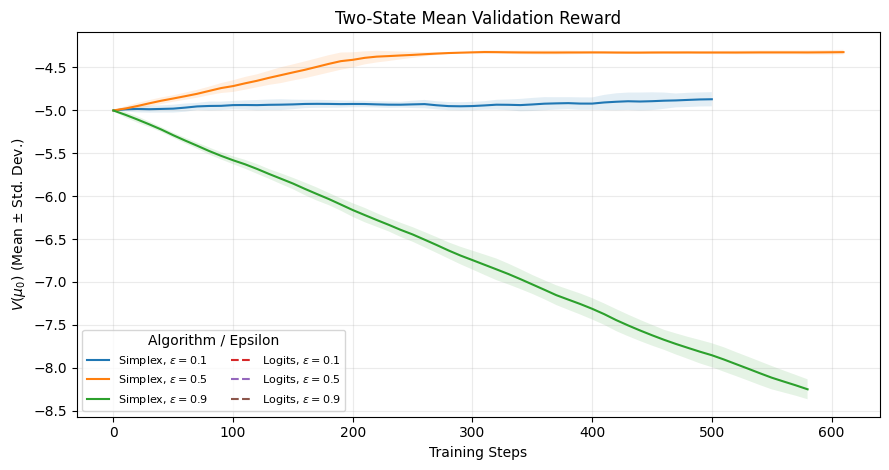

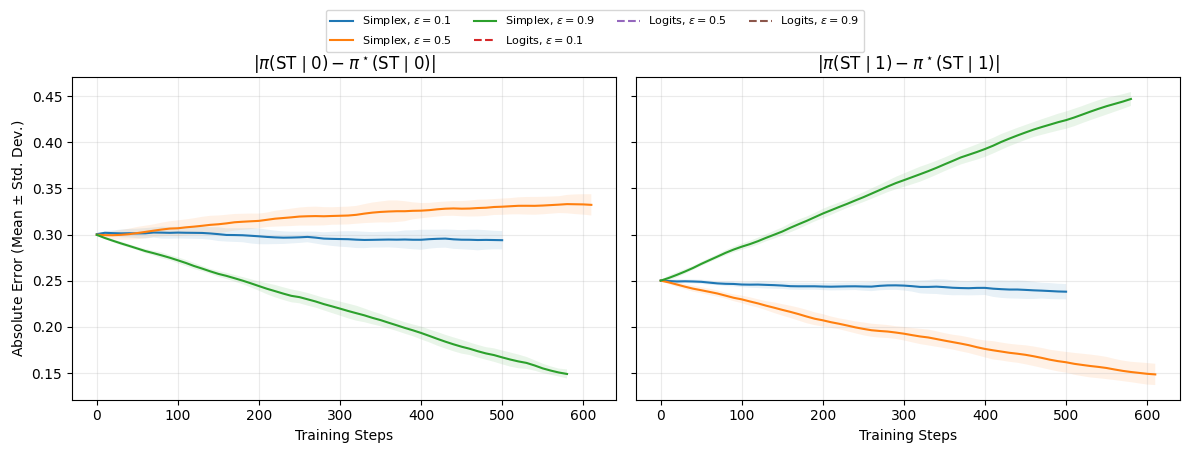

final_value_mean  final_value_std  avg_abs_err_pi(ST|0)  \
algorithm epsilon                                                            
Simplex   0.1               -4.8578           0.0944                0.2943   
          0.5               -4.3178           0.0241                0.3304   
          0.9               -8.6707           0.2828                0.1307   
Logits    0.1               -4.9935           0.0369                0.2995   
          0.5               -4.9679           0.0140                0.3016   
          0.9               -4.9634           0.0079                0.3013   

                   std_abs_err_pi(ST|0)  avg_abs_err_pi(ST|1)  \
algorithm epsilon                                               
Simplex   0.1                    0.0104                0.2372   
          0.5                    0.0107                0.1468   
          0.9                    0.0129                0.4711   
Logits    0.1                    0.0025                0.2494   
          0.5                    0.0020                0.2480   
          0.9                    0.0004                0.2475   

                   std_abs_err_pi(ST|1)  avg_abs_err_policy  \
algorithm epsilon                                             
Simplex   0.1                    0.0085              0.2657   
          0.5                    0.0103              0.2386   
          0.9                    0.0162              0.3009   
Logits    0.1                    0.0025              0.2744   
          0.5                    0.0007              0.2748   
          0.9                    0.0006              0.2744   

                   runtime_seconds_mean  episodes_completed_mean  
algorithm epsilon                                                 
Simplex   0.1                  540.2539                    639.0  
          0.5                  540.6877                    641.8  
          0.9                  540.5030                    678.6  
Logits    0.1                  591.7668                      8.2  
          0.5                  567.3784                      8.4  
          0.9                  591.6035                      8.0

In [8]:
# Combined two-state results
twostate_result_groups = {
    "Simplex": results_twostate,
    "Logits": results_logits_twostate,
}
line_styles = {"Simplex": "-", "Logits": "--"}
std_ddof = 1 if config.training_runs > 1 else 0
table_rows = []

def aligned_history_metric(runs, key: str):
    min_len = min(len(run["history"][key]) for run in runs)
    episodes = np.asarray(runs[0]["history"]["episode"][:min_len], dtype=float)
    values = np.asarray([run["history"][key][:min_len] for run in runs], dtype=float)
    return episodes, values

fig, ax = plt.subplots(figsize=(9, 4.8))

for algorithm_name, result_group in twostate_result_groups.items():
    for eps in epsilon_range:
        runs = result_group[eps]
        episodes, validation_rewards = aligned_validation_history(runs)
        reward_mean = validation_rewards.mean(axis=0)
        reward_std = validation_rewards.std(axis=0, ddof=std_ddof)
        label = rf"{algorithm_name}, $\varepsilon={eps}$"
        ax.plot(episodes, reward_mean, linestyle=line_styles[algorithm_name], label=label)
        ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.12)

        pi_star = runs[0]["optimal_policy"].detach().cpu().numpy()
        final_policies = np.asarray(
            [run["final_policy"].detach().cpu().numpy() for run in runs],
            dtype=float,
        )
        st_errors = np.abs(final_policies[:, :, 0] - pi_star[:, 0])
        final_values = np.asarray([run["final_value"] for run in runs], dtype=float)
        runtimes = np.asarray([run["runtime_seconds"] for run in runs], dtype=float)
        episodes_completed = np.asarray([run["episodes_completed"] for run in runs], dtype=float)

        table_rows.append(
            {
                "algorithm": algorithm_name,
                "epsilon": eps,
                "final_value_mean": final_values.mean(),
                "final_value_std": final_values.std(ddof=std_ddof),
                "avg_abs_err_pi(ST|0)": st_errors[:, 0].mean(),
                "std_abs_err_pi(ST|0)": st_errors[:, 0].std(ddof=std_ddof),
                "avg_abs_err_pi(ST|1)": st_errors[:, 1].mean(),
                "std_abs_err_pi(ST|1)": st_errors[:, 1].std(ddof=std_ddof),
                "avg_abs_err_policy": st_errors.mean(axis=1).mean(),
                "runtime_seconds_mean": runtimes.mean(),
                "episodes_completed_mean": episodes_completed.mean(),
            }
        )

ax.set_title("Two-State Mean Validation Reward")
ax.set_xlabel("Training Steps")
ax.set_ylabel(r"$V(\mu_0)$ (Mean $\pm$ Std. Dev.)")
ax.legend(title="Algorithm / Epsilon", ncol=2, fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
state_error_keys = ["err_pi_st_0", "err_pi_st_1"]
state_titles = [r"$|\pi(\mathrm{ST}\mid0)-\pi^\star(\mathrm{ST}\mid0)|$", r"$|\pi(\mathrm{ST}\mid1)-\pi^\star(\mathrm{ST}\mid1)|$"]

for ax, key, title in zip(axes, state_error_keys, state_titles):
    for algorithm_name, result_group in twostate_result_groups.items():
        for eps in epsilon_range:
            runs = result_group[eps]
            episodes, errors = aligned_history_metric(runs, key)
            error_mean = errors.mean(axis=0)
            error_std = errors.std(axis=0, ddof=std_ddof)
            label = rf"{algorithm_name}, $\varepsilon={eps}$"
            ax.plot(episodes, error_mean, linestyle=line_styles[algorithm_name], label=label)
            ax.fill_between(episodes, error_mean - error_std, error_mean + error_std, alpha=0.10)
    ax.set_title(title)
    ax.set_xlabel("Training Steps")
    ax.grid(alpha=0.25)

axes[0].set_ylabel(r"Absolute Error (Mean $\pm$ Std. Dev.)")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.08), ncol=4, fontsize=8)
fig.tight_layout()
plt.show()

table_1 = pd.DataFrame(table_rows).set_index(["algorithm", "epsilon"])
display(table_1.round(4))


## 2. Cybersecurity Example [Meunier2026][25][6]

We consider a large population of computers.

Four states:
- DI: defended and infected
- DS: defended and susceptible
- UI: undefended and infected
- US: undefended and susceptible

Action space is $\mathcal A = \{0,1\}$, where $0$ means keeping the same level of protection $\mathrm D$ or $\mathrm U$, and $1$ means updating the level of protection (from $\mathrm D$ to $\mathrm U$ or vice versa).

When infected, the computer recovers at rate $q_\mathrm{rec}^D$ or $q_\mathrm{rec}^U$ depending on the level of protection. When susceptible, the computer might
be infected either directly by a hacker or by the other infected computers, at rates depending on the level of protection of the susceptible computer and the other infected computers.

Originally the problem was formulated in continuous time, and the infinitesimal generator matrix can be written, given the current distribution of the population $\mu$ and action chosen by the computer $a$, as
\begin{align}
    Q^{\mu, a} =
    \begin{pmatrix}
        \dots & q_{\mathrm{rec}}^D & \lambda a & 0 \\
        Q_{\mathrm{DS} \rightarrow \mathrm{DI}}^{\mu, a} & \dots & 0 & \lambda a \\
        \lambda a & 0 & \dots & q_\mathrm{rec}^U \\
        0 & \lambda a & Q_{\mathrm{US} \rightarrow \mathrm{UI}} & \dots  
    \end{pmatrix},
\end{align}
where
\begin{align}
    Q_{\mathrm{DS} \rightarrow \mathrm{DI}}^{\mu, a} &= v_H q_\mathrm{inf}^D + \beta_{\mathrm{DD}}\mu(\mathrm{DI}) + \beta_{\mathrm{UD}}\mu(UI), \\
    Q_{\mathrm{US} \rightarrow \mathrm{UI}}^{\mu, a} &= v_H q_\mathrm{inf}^U + \beta_\mathrm{UU}\mu(\mathrm{UI}) + \beta_\mathrm{DU}\mu(\mathrm{DI}),
\end{align}
and all instances of $\dots$ should be replaced by values to make each row sum to $0$.

Each computer incurs a cost whenever it is defended or infected. The individual cost per unit of time is given by $f(x) = k_D\mathbf 1_{x\in\{\mathrm{DI}, \mathrm{DS}\}} + k_I\mathbf 1_{x\in\{\mathrm{DI},\mathrm{UI} \}}.

The model is adapted to a discrete time setting by considering a time grid $0, \Delta t, 2\Delta t, \ldots, N_{\mathrm{epi}}\Delta t$. Between two points of the time grid, the transition matrix is given by $P_{\Delta t}^{\mu, a} = \exp(\Delta t Q^{\mu, a})$, and the running reward is $r_{\Delta t}(x, a, \mu) = r_{\Delta t}(x) = -\Delta t f(x)$.

For the numerical experiments, we use the same values for the parameters as in [Meunier2026]. The rewards are discounted by $\gamma =0.5$ and the terminal reward is taken to be the same as the running reward.

The training and evaluation are done as follows. As the transition probability is stationary and the terminal reward is the same as the step reward, the length of a training episode is taken to be $T_\mathrm{train}=3$ to mitigate the "curse of time" (cf. [Meunier2026] - Remark 3.2), and for each training episode we simulate the population starting from a random initial distribution $\mu\in \mathcal P(\mathcal X)^\star$. Every 10 training episodes, we freeze the policy and sample a validation episode of length $T_\mathrm{val}=50$, for which we compute the population reward $V(\mu_0)$ starting from a fixed initial distribution $\mu_0=(1/4, 1/4, 1/4, 1/4).
During training, the implementation below uses the same simplex-perturbed empirical-flow framework as in Problem 1. We compute $N=200$ main perturbed trajectories, estimate the unperturbed population flow from simulated particles, and use $n$ auxiliary trajectories for the population-flow sensitivity estimator. The policy is given by a 2-layer MLP, with 32 hidden units and tanh activations; it takes as input $t, \mu$ and outputs a $|\mathcal X|\times |\mathcal A|$ matrix corresponding to the probability of each action given each state.
We use the Adam optimizer with learning rate $10^{-3}$.
The experiments below use simplex perturbations $\varepsilon \in (0,1)$.

FINDINGS: We clearly see the effect of $\varepsilon$ on the variance of the overall training algorithm: the smaller the perturbation, the more erratic the gradient estimation becomes, which leads to slower convergence. Surprisingly, taking a smaller
value of epsilon does not lead to a better policy. To confirm that the policy obtained is not suboptimal, we compare the state distribution evolution under the learned policy to the results obtained in [6] with mean-field Q-learning. The resulting flow of distributions is shown in Figure 3. Clearly, we see that the qualitative behaviour of the population under the policy learned using
MF-REINFORCE eventually matches the one learned using mean-field Q-learning in [6].


In [9]:
# Configuration and parameters
config = CybersecurityConfig(device=device, dtype=torch.float64)

flow_particles = 200
epsilon_range = [0.1, 0.5, 0.9]
early_stopping_patience = 100 # Validation checks without improvement before stopping; set None to disable
early_stopping_min_delta = 1e-4
max_runtime_seconds = 9 * 60 # Per epsilon/run wall-clock budget; set None to disable


In [10]:
# Training
results_cybersecurity = train_simplex_mfreinforce(
    CybersecurityMFC,
    config,
    epsilon_range,
    flow_particles,
    policy_cls=CybersecurityPolicy,
    label="Cybersecurity",
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    max_runtime_seconds=max_runtime_seconds,
)


Cybersecurity eps=0.1 run=0:   1%|          | 151/20000 [09:03<19:50:16,  3.60s/it, elapsed=8m 59s, val=-0.1597]


Cybersecurity eps=0.1 run=0: 152 episodes, runtime=9m 03s, stop=runtime, final_value=-0.159695, saved=/home/adonis/Internship/MFC_RL/models/SimplexMFREINFORCE/cybersecurity/eps0p1_run0.pt


Cybersecurity eps=0.1 run=1:   1%|          | 152/20000 [09:01<19:37:24,  3.56s/it, elapsed=8m 53s, val=-0.1597]


Cybersecurity eps=0.1 run=1: 153 episodes, runtime=9m 01s, stop=runtime, final_value=-0.159689, saved=/home/adonis/Internship/MFC_RL/models/SimplexMFREINFORCE/cybersecurity/eps0p1_run1.pt


Cybersecurity eps=0.1 run=2:   1%|          | 146/20000 [09:00<20:24:35,  3.70s/it, elapsed=8m 37s, val=-0.1583]


...

Cybersecurity eps=0.9 run=2: 144 episodes, runtime=9m 03s, stop=runtime, final_value=-0.157271, saved=/home/adonis/Internship/MFC_RL/models/SimplexMFREINFORCE/cybersecurity/eps0p9_run2.pt


Cybersecurity eps=0.9 run=3:   1%|          | 140/20000 [09:01<21:20:15,  3.87s/it, elapsed=9m 01s, val=-0.1588]


Cybersecurity eps=0.9 run=3: 141 episodes, runtime=9m 01s, stop=runtime, final_value=-0.158831, saved=/home/adonis/Internship/MFC_RL/models/SimplexMFREINFORCE/cybersecurity/eps0p9_run3.pt


Cybersecurity eps=0.9 run=4:   1%|          | 154/20000 [09:02<19:24:46,  3.52s/it, elapsed=8m 48s, val=-0.1586]

Cybersecurity eps=0.9 run=4: 155 episodes, runtime=9m 02s, stop=runtime, final_value=-0.158525, saved=/home/adonis/Internship/MFC_RL/models/SimplexMFREINFORCE/cybersecurity/eps0p9_run4.pt
=== Cybersecurity training completed for eps=0.9 over 5 runs ===
Runtime for eps=0.9: 45m 08s
Final validation values: [-0.15851947110993725, -0.1584348904904231, -0.15727138146714606, -0.1588314247938104, -0.15852544607900848]

Total Cybersecurity training runtime: 2h 15m 23s


In [11]:
# Logits training
results_logits_cybersecurity = train_logits_mfreinforce(
    CybersecurityMFC,
    config,
    epsilon_range,
    flow_particles,
    policy_cls=CybersecurityPolicy,
    label="Cybersecurity",
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    max_runtime_seconds=max_runtime_seconds,
)


Cybersecurity logits eps=0.1 run=0:   0%|          | 1/20000 [14:43<4908:16:10, 883.53s/it, elapsed=6m 52s, val=-0.1594]


Cybersecurity logits eps=0.1 run=0: 2 episodes, runtime=14m 43s, stop=runtime, final_value=-0.159452, saved=/home/adonis/Internship/MFC_RL/models/LogitsMFREINFORCE/cybersecurity/eps0p1_run0.pt


Cybersecurity logits eps=0.1 run=1:   0%|          | 1/20000 [13:44<4577:44:47, 824.04s/it, elapsed=6m 34s, val=-0.1588]


Cybersecurity logits eps=0.1 run=1: 2 episodes, runtime=13m 44s, stop=runtime, final_value=-0.158775, saved=/home/adonis/Internship/MFC_RL/models/LogitsMFREINFORCE/cybersecurity/eps0p1_run1.pt


Cybersecurity logits eps=0.1 run=2:   0%|          | 1/20000 [14:31<4840:25:39, 871.32s/it, elapsed=7m 48s, val=-0.1595]


...

Cybersecurity logits eps=0.9 run=1: 2 episodes, runtime=14m 13s, stop=runtime, final_value=-0.159298, saved=/home/adonis/Internship/MFC_RL/models/LogitsMFREINFORCE/cybersecurity/eps0p9_run1.pt


Cybersecurity logits eps=0.9 run=2:   0%|          | 1/20000 [13:21<4450:17:21, 801.09s/it, elapsed=6m 46s, val=-0.1585]


Cybersecurity logits eps=0.9 run=2: 2 episodes, runtime=13m 21s, stop=runtime, final_value=-0.15853, saved=/home/adonis/Internship/MFC_RL/models/LogitsMFREINFORCE/cybersecurity/eps0p9_run2.pt


Cybersecurity logits eps=0.9 run=3:   0%|          | 1/20000 [12:59<4332:58:15, 779.97s/it, elapsed=6m 36s, val=-0.1593]


KeyboardInterrupt: 

In [12]:
# Sanity Check
sanity_eps = epsilon_range[0]
policy = CybersecurityPolicy(config)
policy.load_state_dict(results_cybersecurity[sanity_eps][0]["policy_state"])
eps_law, eta_aux = sanity_eps, sanity_eps
B: int = 512
n_aux: int = 64
flow_particles: int = 1_000
n_q_oracle: int = 512


env = CybersecurityMFC(config)
algorithm = SimplexPerturbedMFREINFORCE(env)
mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)
mu_hat_flow = algorithm.estimate_population_flow(policy, mu0, flow_particles, horizon=config.T_train)
exact_flow = env.exact_population_flow(policy, mu0, config.T_train).detach()
D_hat = algorithm.estimate_sensitivity(policy, mu_hat_flow, eta_aux, n_aux)
grad_hat, diag = algorithm.gradient_estimate(policy, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")

# Compute the exact perturbed value with MC
algorithm = SimplexPerturbedMFREINFORCE(env)
exact_flow = env.exact_population_flow(policy, mu0, config.T_train)
q_paths = algorithm.sample_q_batch(n_q_oracle * (config.T_train + 1)).reshape(n_q_oracle, config.T_train + 1, env.n_states)
value = torch.zeros((), dtype=env.config.dtype, device=env.config.device)

for r in range(n_q_oracle):
    state_law = mu0
    for t in range(config.T_train):
        M_t = (1.0 - eps_law) * exact_flow[t] + eps_law * q_paths[r, t]
        value = value + (env.config.gamma ** t) * (state_law * env.reward_by_state).sum()
        state_law = state_law @ env.averaged_kernel(policy, t, M_t)
    M_T = (1.0 - eps_law) * exact_flow[config.T_train] + eps_law * q_paths[r, config.T_train]
    value = value + (env.config.gamma ** config.T_train) * (state_law * env.reward_by_state).sum()

value = value / n_q_oracle

# Compute the exact perturbed gradient with MC
grads = torch.autograd.grad(value, tuple(policy.parameters()))
J_lam, grad_J_lam = value.detach(), torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

# Compute the exact unperturbed gradient
value = env.exact_value(policy, mu0, config.T_train)
grads = torch.autograd.grad(value, tuple(policy.parameters()))
J, grad_J = value.detach(), torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

# Helper cosine function
def cyber_cosine(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x @ y / denom).item())

print("Cosine vs grad J_lambda:", cyber_cosine(grad_hat, grad_J_lam))
print("Cosine vs grad J:", cyber_cosine(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow).sum().item()))
print("Mean Return:", float(diag["mean_return"].item()))
print("Std. Return:", float(diag["std_return"].item()))


Cosine vs grad J_lambda: -0.799169131382821
Cosine vs grad J: -0.799042984029212
Norm G_hat: 41.42059459717988
Norm grad J_lambda: 0.0034354338485918334
Norm grad J: 0.0034354321726552174
J_lambda oracle MC: -0.1497935450864922
J oracle: -0.14977945575984625
Empirical flow L1 error: 0.27061086300409243
Mean Return: -0.14611328125
Std. Return: 0.1001855254570659


### Logits Gradient Sanity Check

For cybersecurity, the logits-perturbed estimator is checked against an autograd Monte Carlo oracle using Gaussian perturbations of the exact population-flow logits and the same discounted validation objective.

In [13]:
# Logits sanity check
sanity_eps = epsilon_range[0]
policy = CybersecurityPolicy(config)
policy.load_state_dict(results_logits_cybersecurity[sanity_eps][0]["policy_state"])
eps_law = sanity_eps
B: int = 20 # Consider bigger values for the check
n_logit: int = 10 # Consider bigger values for the check
flow_particles_check: int = 500
n_lambda_oracle: int = 512

env = CybersecurityMFC(config)
algorithm = LogitsPerturbedMFREINFORCE(env)
mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)

mu_hat_flow = algorithm.estimate_population_flow(policy, mu0, flow_particles_check, horizon=config.T_train)
exact_flow_detached = env.exact_population_flow(policy, mu0, config.T_train).detach()
grad_hat, diag = algorithm.gradient_estimate(policy, mu0, eps_law, B, n_logit, flow_particles_check, horizon=config.T_train)

# Compute the exact logit-perturbed value with MC
exact_flow = env.exact_population_flow(policy, mu0, config.T_train)
logit_flow = torch.stack([algorithm.logit(mu_t) for mu_t in exact_flow])
value = torch.zeros((), dtype=env.config.dtype, device=env.config.device)

for r in range(n_lambda_oracle):
    state_law = mu0
    lambdas = algorithm.sample_lambda(config.T_train)
    for t in range(config.T_train):
        M_t = algorithm.perturb_law(logit_flow[t], eps_law, lambdas[t])
        value = value + (env.config.gamma ** t) * (state_law * env.reward_by_state).sum()
        state_law = state_law @ env.averaged_kernel(policy, t, M_t)
    M_T = algorithm.perturb_law(logit_flow[config.T_train], eps_law, lambdas[config.T_train])
    value = value + (env.config.gamma ** config.T_train) * (state_law * env.reward_by_state).sum()

value = value / n_lambda_oracle

grads = torch.autograd.grad(value, tuple(policy.parameters()))
J_lam, grad_J_lam = value.detach(), torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

value = env.exact_value(policy, mu0, config.T_train)
grads = torch.autograd.grad(value, tuple(policy.parameters()))
J, grad_J = value.detach(), torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

def cyber_logits_cosine(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x @ y / denom).item())

print("Cosine vs grad J_lambda:", cyber_logits_cosine(grad_hat, grad_J_lam))
print("Cosine vs grad J:", cyber_logits_cosine(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow_detached).sum().item()))
print("Mean Return:", float(diag["mean_return"].item()))
print("Std. Return:", float(diag["std_return"].item()))


NameError: name 'results_logits_cybersecurity' is not defined

### Results


KeyError: 0.75

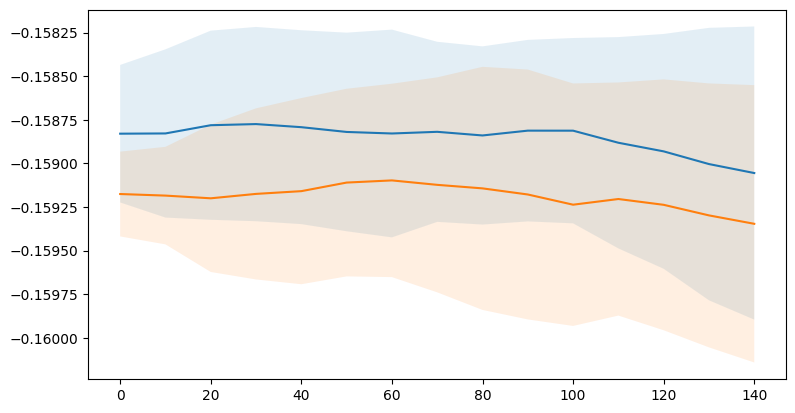

In [ ]:
# Combined cybersecurity results
cyber_result_groups = {
    "Simplex": results_cybersecurity,
    "Logits": results_logits_cybersecurity,
}
line_styles = {"Simplex": "-", "Logits": "--"}
cyber_std_ddof = 1 if config.training_runs > 1 else 0
table_rows = []

fig, ax = plt.subplots(figsize=(9, 4.8))

for algorithm_name, result_group in cyber_result_groups.items():
    for eps in epsilon_range:
        runs = result_group[eps]
        episodes, validation_rewards = aligned_validation_history(runs)
        reward_mean = validation_rewards.mean(axis=0)
        reward_std = validation_rewards.std(axis=0, ddof=cyber_std_ddof)
        label = f"{algorithm_name}, epsilon={eps}"
        ax.plot(episodes, reward_mean, linestyle=line_styles[algorithm_name], label=label)
        ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.12)

        final_values = np.asarray([run["final_value"] for run in runs], dtype=float)
        runtimes = np.asarray([run["runtime_seconds"] for run in runs], dtype=float)
        episodes_completed = np.asarray([run["episodes_completed"] for run in runs], dtype=float)
        table_rows.append({
            "algorithm": algorithm_name,
            "epsilon": eps,
            "final_value_mean": final_values.mean(),
            "final_value_std": final_values.std(ddof=cyber_std_ddof),
            "runtime_seconds_mean": runtimes.mean(),
            "episodes_completed_mean": episodes_completed.mean(),
        })

ax.set_title("Cybersecurity Mean Validation Reward")
ax.set_xlabel("Training Steps")
ax.set_ylabel(r"$V(\mu_0)$ (Mean $\pm$ Std. Dev.)")
ax.legend(title="Algorithm / Epsilon", ncol=2, fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

table_cybersecurity = pd.DataFrame(table_rows).set_index(["algorithm", "epsilon"])
display(table_cybersecurity.round(4))

flow_eps = 0.5 if 0.5 in epsilon_range else epsilon_range[0]
fixed_mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)

# Benchmark values from Carmona, Laurière, Tan 2021
mfq_final_benchmark = {
    "UI": 0.43,
    "US": 0.57,
}

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True, sharey=True)
axes = axes.ravel()

for state_idx, state_name in enumerate(config.cyber_state_names):
    ax = axes[state_idx]
    for algorithm_name, result_group in cyber_result_groups.items():
        env = CybersecurityMFC(config)
        policy = CybersecurityPolicy(config)
        policy.load_state_dict(result_group[flow_eps][0]["policy_state"])
        with torch.no_grad():
            flow = env.exact_population_flow(policy, fixed_mu0, config.T_val).cpu().numpy()
        ax.plot(np.arange(config.T_val + 1), flow[:, state_idx], linestyle=line_styles[algorithm_name], label=algorithm_name)
    if state_name in mfq_final_benchmark:
        ax.axhline(mfq_final_benchmark[state_name], linestyle=":", color="0.35", label="MFQ benchmark")
    ax.set_title(state_name)
    ax.set_xlabel("Time")
    ax.set_ylabel("State probability")
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.02), ncol=3)
fig.suptitle(f"Cybersecurity State Distributions (epsilon={flow_eps})", y=1.08)
fig.tight_layout()
plt.show()


## 3. Distribution Planning Example [Meunier2026][6]

Consider a problem similar to the distribution planning example of [6] (Section 6.2). The goal is to match a fixed target distribution $\mu_\mathrm{target}\in\mathcal P(\mathcal X)$, where $\mathcal X=\mathbb Z/10\mathbb Z$. The action space is $\mathcal A=\{-1,0,+1\}$, and the transition probability is deterministic $P(\cdot\mid x,a,\mu)=\delta_{x+a}$. At each step, we penalize the deviation of the population from the target distribution and penalize movement: $r(x,a,\mu)=-\lambda |a|-\sum_{y\in\mathcal X}|\mu(y)-\mu_\mathrm{target}(y)|^2$. The terminal reward is $g(x,\mu)=-\sum_{y\in\mathcal X}|\mu(y)-\mu_\mathrm{target}(y)|^2$.

We use $T=5$, $\lambda=0.01$, $N=500$, $n=10$, an MLP policy with two hidden layers of width 256 and tanh activations, Adam with learning rate $10^{-4}$, and $\varepsilon\in\{0.5,0.75,1.0,2.0\}$. Validation starts from $\mu_0=\mathcal U(\mathcal X)$.


In [15]:
# Configuration and parameters
config = DistributionPlanningConfig(device=device, dtype=torch.float64)

flow_particles = 500
epsilon_range = [0.1, 0.5, 0.75]
early_stopping_patience = 100 # Validation checks without improvement before stopping; set None to disable
early_stopping_min_delta = 1e-4
max_runtime_seconds = 9 * 60 # Per epsilon/run wall-clock budget; set None to disable


In [16]:
# Training
results_distribution_planning = train_simplex_mfreinforce(
    DistributionPlanningMFC,
    config,
    epsilon_range,
    flow_particles,
    policy_cls=DistributionPlanningPolicy,
    save_final_distribution=True,
    label="Distribution planning",
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    max_runtime_seconds=max_runtime_seconds,
)


Distribution planning eps=0.1 run=0:   0%|          | 30/100000 [04:05<226:47:19,  8.17s/it, elapsed=2m 48s, val=-0.2817]


KeyboardInterrupt: 

In [ ]:
# Logits training
results_logits_distribution_planning = train_logits_mfreinforce(
    DistributionPlanningMFC,
    config,
    epsilon_range,
    flow_particles,
    policy_cls=DistributionPlanningPolicy,
    save_final_distribution=True,
    label="Distribution planning",
    early_stopping_patience=early_stopping_patience,
    early_stopping_min_delta=early_stopping_min_delta,
    max_runtime_seconds=max_runtime_seconds,
)


In [ ]:
# Sanity check
sanity_eps = 1.0 if 1.0 in results_distribution_planning else epsilon_range[0]
eps_law, eta_aux = sanity_eps, sanity_eps
B = 512
n_aux_check = 64
flow_particles_check = 1_000
n_q_oracle = 512

env = DistributionPlanningMFC(config)
policy = DistributionPlanningPolicy(config)
policy.load_state_dict(results_distribution_planning[sanity_eps][0]["policy_state"])
algorithm = SimplexPerturbedMFREINFORCE(env)
mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)

mu_hat_flow = algorithm.estimate_population_flow(policy, mu0, flow_particles_check, horizon=config.T)
exact_flow_detached = env.exact_population_flow(policy, mu0, config.T).detach()
D_hat = algorithm.estimate_sensitivity(policy, mu_hat_flow, eta_aux, n_aux_check)
grad_hat, diag = algorithm.gradient_estimate(policy, mu_hat_flow, D_hat, eps_law, B, baseline="batch_mean")

exact_flow = env.exact_population_flow(policy, mu0, config.T)
q_paths = algorithm.sample_q_batch(n_q_oracle * (config.T + 1)).reshape(n_q_oracle, config.T + 1, env.n_states)
value = torch.zeros((), dtype=config.dtype, device=config.device)

for r in range(n_q_oracle):
    state_law = mu0
    for t in range(config.T):
        M_t = (1.0 - eps_law) * exact_flow[t] + eps_law * q_paths[r, t]
        pi = policy.probs(t, M_t)
        step_reward = torch.zeros((), dtype=config.dtype, device=config.device)
        for x in range(config.n_states):
            for a in range(config.n_actions):
                step_reward = step_reward + state_law[x] * pi[x, a] * env.reward(x, M_t, a)
        value = value + step_reward
        state_law = state_law @ env.averaged_kernel(policy, t, M_t)
    M_T = (1.0 - eps_law) * exact_flow[config.T] + eps_law * q_paths[r, config.T]
    value = value + env.terminal_reward(0, M_T)
value = value / n_q_oracle

grads = torch.autograd.grad(value, tuple(policy.parameters()))
J_lam = value.detach()
grad_J_lam = torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

value = env.exact_value(policy, mu0, config.T)
grads = torch.autograd.grad(value, tuple(policy.parameters()))
J = value.detach()
grad_J = torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

def distribution_cosine(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x @ y / denom).item())

print("Cosine vs grad J_lambda:", distribution_cosine(grad_hat, grad_J_lam))
print("Cosine vs grad J:", distribution_cosine(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow_detached).sum().item()))


### Logits Gradient Sanity Check

For distribution planning, the logits-perturbed estimator is checked against an autograd Monte Carlo oracle using Gaussian perturbations of the exact population-flow logits.

In [ ]:
# Logits sanity check
sanity_eps = 0.5 if 0.5 in results_logits_distribution_planning else epsilon_range[0]
eps_law = sanity_eps
B = 20 # Consider bigger values for the check
n_logit = 10 # Consider bigger values for the check
flow_particles_check = 500
n_lambda_oracle = 512

env = DistributionPlanningMFC(config)
policy = DistributionPlanningPolicy(config)
policy.load_state_dict(results_logits_distribution_planning[sanity_eps][0]["policy_state"])
algorithm = LogitsPerturbedMFREINFORCE(env)
mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)

mu_hat_flow = algorithm.estimate_population_flow(policy, mu0, flow_particles_check, horizon=config.T)
exact_flow_detached = env.exact_population_flow(policy, mu0, config.T).detach()
grad_hat, diag = algorithm.gradient_estimate(policy, mu0, eps_law, B, n_logit, flow_particles_check, horizon=config.T)

exact_flow = env.exact_population_flow(policy, mu0, config.T)
logit_flow = torch.stack([algorithm.logit(mu_t) for mu_t in exact_flow])
value = torch.zeros((), dtype=config.dtype, device=config.device)

for r in range(n_lambda_oracle):
    state_law = mu0
    lambdas = algorithm.sample_lambda(config.T)
    for t in range(config.T):
        M_t = algorithm.perturb_law(logit_flow[t], eps_law, lambdas[t])
        pi = policy.probs(t, M_t)
        step_reward = torch.zeros((), dtype=config.dtype, device=config.device)
        for x in range(config.n_states):
            for a in range(config.n_actions):
                step_reward = step_reward + state_law[x] * pi[x, a] * env.reward(x, M_t, a)
        value = value + step_reward
        state_law = state_law @ env.averaged_kernel(policy, t, M_t)
    M_T = algorithm.perturb_law(logit_flow[config.T], eps_law, lambdas[config.T])
    value = value + env.terminal_reward(0, M_T)
value = value / n_lambda_oracle

grads = torch.autograd.grad(value, tuple(policy.parameters()))
J_lam = value.detach()
grad_J_lam = torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

value = env.exact_value(policy, mu0, config.T)
grads = torch.autograd.grad(value, tuple(policy.parameters()))
J = value.detach()
grad_J = torch.nn.utils.parameters_to_vector([g.detach() for g in grads])

def distribution_logits_cosine(x: torch.Tensor, y: torch.Tensor) -> float:
    denom = torch.linalg.norm(x) * torch.linalg.norm(y)
    if float(denom.item()) == 0.0:
        return float("nan")
    return float((x @ y / denom).item())

print("Cosine vs grad J_lambda:", distribution_logits_cosine(grad_hat, grad_J_lam))
print("Cosine vs grad J:", distribution_logits_cosine(grad_hat, grad_J))
print("Norm G_hat:", float(torch.linalg.norm(grad_hat).item()))
print("Norm grad J_lambda:", float(torch.linalg.norm(grad_J_lam).item()))
print("Norm grad J:", float(torch.linalg.norm(grad_J).item()))
print("J_lambda oracle MC:", float(J_lam.item()))
print("J oracle:", float(J.item()))
print("Empirical flow L1 error:", float(torch.abs(mu_hat_flow - exact_flow_detached).sum().item()))
print("Mean Return:", float(diag["mean_return"].item()))
print("Std. Return:", float(diag["std_return"].item()))


In [ ]:
# Combined distribution planning results
distribution_result_groups = {
    "Simplex": results_distribution_planning,
    "Logits": results_logits_distribution_planning,
}
line_styles = {"Simplex": "-", "Logits": "--"}
distribution_std_ddof = 1 if config.training_runs > 1 else 0
table_rows = []

env = DistributionPlanningMFC(config)
fixed_mu0 = torch.full((config.n_states,), 1.0 / config.n_states, dtype=config.dtype, device=config.device)
target = env.target.detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(9, 4.8))

for algorithm_name, result_group in distribution_result_groups.items():
    for eps in epsilon_range:
        runs = result_group[eps]
        episodes, validation_rewards = aligned_validation_history(runs)
        reward_mean = validation_rewards.mean(axis=0)
        reward_std = validation_rewards.std(axis=0, ddof=distribution_std_ddof)
        label = f"{algorithm_name}, epsilon={eps}"
        ax.plot(episodes, reward_mean, linestyle=line_styles[algorithm_name], label=label)
        ax.fill_between(episodes, reward_mean - reward_std, reward_mean + reward_std, alpha=0.12)

        final_distributions = np.asarray([run["final_distribution"].numpy() for run in runs], dtype=float)
        final_values = np.asarray([run["final_value"] for run in runs], dtype=float)
        runtimes = np.asarray([run["runtime_seconds"] for run in runs], dtype=float)
        episodes_completed = np.asarray([run["episodes_completed"] for run in runs], dtype=float)
        table_rows.append({
            "algorithm": algorithm_name,
            "epsilon": eps,
            "final_value_mean": final_values.mean(),
            "final_value_std": final_values.std(ddof=distribution_std_ddof),
            "final_l2_to_target": np.linalg.norm(final_distributions - target, axis=1).mean(),
            "runtime_seconds_mean": runtimes.mean(),
            "episodes_completed_mean": episodes_completed.mean(),
        })

ax.set_title("Distribution Planning Mean Validation Reward")
ax.set_xlabel("Training Steps")
ax.set_ylabel(r"$V(\mu_0)$ (Mean $\pm$ Std. Dev.)")
ax.legend(title="Algorithm / Epsilon", ncol=2, fontsize=8)
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

table_distribution = pd.DataFrame(table_rows).set_index(["algorithm", "epsilon"])
display(table_distribution.round(4))

figure_eps = [eps for eps in [0.5, 0.75] if eps in epsilon_range]
if not figure_eps:
    figure_eps = [epsilon_range[0]]
states = np.arange(config.n_states)
initial = np.full(config.n_states, 1.0 / config.n_states)
bar_width = 0.2

for eps in figure_eps:
    fig, ax = plt.subplots(figsize=(10, 4.8))
    offsets = {
        "Initial": -1.5 * bar_width,
        "Target": -0.5 * bar_width,
        "Simplex": 0.5 * bar_width,
        "Logits": 1.5 * bar_width,
    }
    ax.bar(states + offsets["Initial"], initial, width=bar_width, label="Initial", alpha=0.45)
    ax.bar(states + offsets["Target"], target, width=bar_width, label="Target", alpha=0.75)
    for algorithm_name, result_group in distribution_result_groups.items():
        final_distributions = np.asarray([run["final_distribution"].numpy() for run in result_group[eps]], dtype=float)
        ax.bar(states + offsets[algorithm_name], final_distributions.mean(axis=0), width=bar_width, label=algorithm_name)
    ax.set_title(f"Final State Distribution by Algorithm (epsilon={eps})")
    ax.set_xlabel("State")
    ax.set_ylabel("Probability")
    ax.set_xticks(states)
    ax.set_ylim(0.0, max(0.25, 1.1 * max(target.max(), initial.max())))
    ax.legend()
    ax.grid(axis="y", alpha=0.35)
    fig.tight_layout()
    plt.show()
